In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json
from datetime import datetime
import wandb

In [ ]:
pip install geopandas

# Early stopping class

In [5]:
class EarlyStopping:
    def __init__(self, patience=15, delta=0.0001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Loss Functions

In [6]:
# class QuantileLoss(nn.Module):
#     def __init__(self, quantile=0.9):
#         super().__init__()
#         self.quantile = quantile

#     def forward(self, pred, target):
#         error = target - pred
#         return torch.max(self.quantile * error, (self.quantile - 1) * error).mean()

In [7]:
class WeibullWeightedMSELoss(nn.Module):
    def __init__(self, kappa=28.0, alpha=2.75, eps=1e-6):
        super().__init__()
        self.kappa = kappa
        self.alpha = alpha
        self.eps = eps

    def forward(self, preds, targets):
        k, a = self.kappa, self.alpha
        pdf = (k/a) * ((targets/a)**(k-1)) * torch.exp(-(targets/a)**k)
        weights = 1.0 / (pdf + self.eps)
        weights = weights / weights.mean()
        return (weights * (preds - targets)**2).mean()

In [8]:
class WeightedMSELoss(nn.Module):
    def __init__(self, threshold=0.2, factor=25):
        super().__init__()
        self.threshold = threshold
        self.factor = factor

    def forward(self, predictions, targets):
        weights = torch.where(
            targets > self.threshold,
            torch.ones_like(targets) * self.factor,
            torch.ones_like(targets)
        )
        return (weights * (predictions - targets) ** 2).mean()

In [9]:
class AsymmetricMSELoss(nn.Module):
    def __init__(self, under_penalty=5.0):
        super().__init__()
        self.under_penalty = under_penalty
    
    def forward(self, pred, target):
        error = pred - target
        loss = torch.where(error < 0,
                          self.under_penalty * error ** 2,  # Under: 5× penalty
                          error ** 2)                        # Over: 1× penalty
        return loss.mean()

In [10]:
class ContinuousWeightedMSELoss(nn.Module):
    def __init__(self, base=1.0, scale=20.0):
        super().__init__()
        self.base = base
        self.scale = scale

    def forward(self, preds, targets):
        weights = self.base + self.scale * targets
        return (weights * (preds - targets) ** 2).mean()

In [11]:
# class HuberLoss(nn.Module):
#     def __init__(self, delta=0.1):
#         """
#         Huber Loss - robust to outliers
        
#         Args:
#             delta: Threshold where loss transitions from quadratic to linear
#                    Smaller delta = more robust to outliers
#         """
#         super().__init__()
#         self.delta = delta
    
#     def forward(self, pred, target):
#         error = torch.abs(pred - target)
        
#         # Quadratic for small errors, linear for large errors
#         quadratic = 0.5 * error ** 2
#         linear = self.delta * (error - 0.5 * self.delta)
        
#         loss = torch.where(error <= self.delta, quadratic, linear)
        
#         return loss.mean()

# CNN Model

In [12]:
class CNN(nn.Module):
    def __init__(self, config):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)

# Dataset Class

In [13]:
class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path):
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1).astype(np.float32)
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1).astype(np.float32)
        with rasterio.open(lc_path) as src:
            self.lc = src.read().astype(np.float32)
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1).astype(np.float32)

        self.valid_mask    = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)
        self.valid_indices = np.argwhere(self.valid_mask)
        print(f"Found {len(self.valid_indices):,} valid pixels")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patch_size = 16
        half_patch = patch_size // 2
        max_tries  = 50
        tries      = 0

        orig_i, orig_j = self.valid_indices[idx]

        while True:
            i, j = self.valid_indices[idx]

            pad_top    = max(0, half_patch - i)
            pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
            pad_left   = max(0, half_patch - j)
            pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])

            i_start = max(0, i - half_patch)
            i_end   = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end   = min(self.gdp.shape[1], j + half_patch)

            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()

            if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
                pad = ((pad_top, pad_bottom), (pad_left, pad_right))
                gdp_patch = np.pad(gdp_patch, pad, mode='edge')
                pop_patch = np.pad(pop_patch, pad, mode='edge')
                lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')

            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break

            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break
            idx = np.random.randint(0, len(self.valid_indices))

        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[orig_i, orig_j]

        return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

# Save function

In [14]:
import torch
import json
from datetime import datetime
import os

def save_model_checkpoint(model, optimizer, train_losses, val_losses, config, save_name, 
                         dataset, train_dataset, val_dataset, criterion, 
                         learning_rate, batch_size, num_epochs, patch_size):
    
    os.makedirs('models', exist_ok=True)
    save_path = f'models/cisi_model_{save_name}.pth'
    
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_losses,
        'val_loss': val_losses,
        'epoch': len(train_losses),
        'best_val_loss': min(val_losses) if val_losses else float('inf'),
        'config': config,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'dataset_info': {
            'patch_size': patch_size,
            'train_samples': len(train_dataset),
            'val_samples': len(val_dataset),
            'total_pixels': len(dataset.valid_indices) if hasattr(dataset, 'valid_indices') else len(dataset),
        },
        'training_info': {
            'loss_function': type(criterion).__name__,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'num_epochs': num_epochs,
            'optimizer': type(optimizer).__name__,
        },
    }
    
    torch.save(checkpoint, save_path)
    print(f"Saved: {save_path}")

# Training Function

In [15]:
def training(
    num_epochs,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    clip_value,
    device,
    scheduler=None,
    wandbrun=None,
    sigmoidcnn=False
):
    train_loss_list = []
    val_loss_list = []

    early_stopping = EarlyStopping()

    for epoch in range(num_epochs):
        # ========== TRAINING ==========
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            inputs, targets, _ = batch
            inputs = inputs.to(device)
            targets = targets.to(device).view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                inputs, targets, _ = batch
                inputs = inputs.to(device)
                targets = targets.to(device).view(-1, 1)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_loss_list.append(avg_val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.6f}")

        # ========== SCHEDULER ========== 
        if scheduler is not None:
            scheduler.step()

        # Early stopping check
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return train_loss_list, val_loss_list

# Paths 0.10

In [16]:
gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif"
pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif"
lc_path = r"READY_data\landuse_onehot\clipped_history_2020_onehot.tif"
cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"

In [17]:
with rasterio.open(r'READY_data\labels\2024_CISI_010deg_nearest.tif') as src:
    data = src.read(1)
    print(f"Shape: {data.shape}")
    print(f"Max: {np.nanmax(data):.4f}")

Shape: (485, 570)
Max: 0.8959


# Paths 0.25

In [18]:
# gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
# pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
# lc_path = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"
# cisi_path = r"READY_data\labels\CISI_025deg_corrected.tif"

In [19]:
# with rasterio.open(r'READY_data\labels\CISI_025deg_corrected.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Dataset and Split

In [ ]:
dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path)
cisi_values = np.array([dataset.cisi[i, j] for i, j in dataset.valid_indices])

high_threshold = 0.15
high_indices = np.where(cisi_values > high_threshold)[0]
low_indices  = np.where(cisi_values <= high_threshold)[0]

np.random.seed(42)
np.random.shuffle(high_indices)
np.random.shuffle(low_indices)

train_idx = np.concatenate([high_indices[:int(0.8*len(high_indices))],
                             low_indices[:int(0.8*len(low_indices))]])
val_idx   = np.concatenate([high_indices[int(0.8*len(high_indices)):],
                             low_indices[int(0.8*len(low_indices)):]])

train_dataset = Subset(dataset, train_idx)
val_dataset   = Subset(dataset, val_idx)

print(f"Train: {len(train_dataset):,}, Val: {len(val_dataset):,}")

cisi_train = cisi_values[train_idx]
n_high = (cisi_train > high_threshold).sum()
n_low  = (cisi_train <= high_threshold).sum()
w_high = len(cisi_train) / n_high
w_low  = len(cisi_train) / n_low
sample_weights = np.where(cisi_train > high_threshold, w_high, w_low)
print(f"Sampler weights — high: {w_high:.1f}x, low: {w_low:.2f}x")

# Create Dataloaders

In [21]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=True)

TRAIN SET:
  Mean: 0.0307, Std: 0.0412
  Range: [0.0000, 0.8959]

VAL SET:
  Mean: 0.0302, Std: 0.0400
  Range: [0.0000, 0.5846]


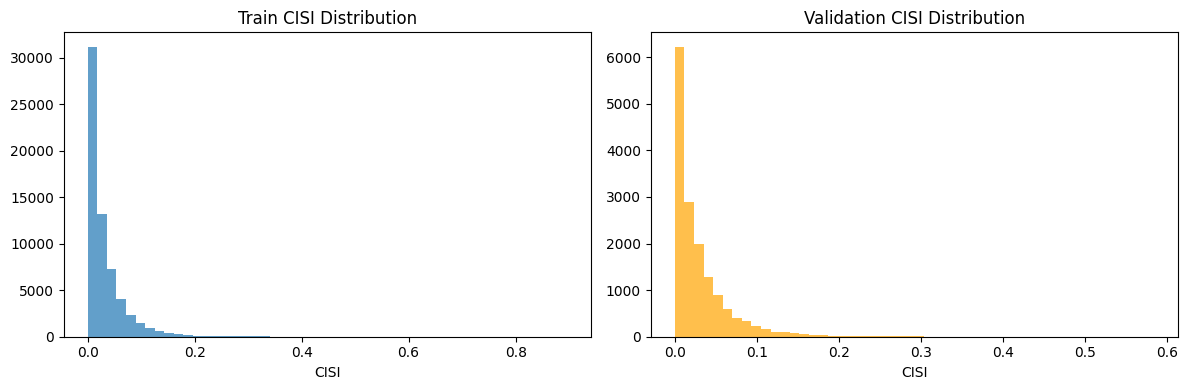

In [22]:
train_targets = []
val_targets = []

for _, target, _ in train_loader:
    train_targets.extend(target.numpy().flatten())

for _, target, _ in val_loader:
    val_targets.extend(target.numpy().flatten())

train_targets = np.array(train_targets)
val_targets = np.array(val_targets)

print("TRAIN SET:")
print(f"  Mean: {train_targets.mean():.4f}, Std: {train_targets.std():.4f}")
print(f"  Range: [{train_targets.min():.4f}, {train_targets.max():.4f}]")

print("\nVAL SET:")
print(f"  Mean: {val_targets.mean():.4f}, Std: {val_targets.std():.4f}")
print(f"  Range: [{val_targets.min():.4f}, {val_targets.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_targets, bins=50, alpha=0.7, label='Train')
axes[0].set_title('Train CISI Distribution')
axes[0].set_xlabel('CISI')

axes[1].hist(val_targets, bins=50, alpha=0.7, label='Val', color='orange')
axes[1].set_title('Validation CISI Distribution')
axes[1].set_xlabel('CISI')

plt.tight_layout()
plt.show()

# Init Model

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = {'dropout': 0.3}
model = CNN(config).to(device)
criterion = WeibullWeightedMSELoss(kappa=28.0, alpha=2.75)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

Using device: cpu


# Train Model

In [22]:
# vars
nummber_of_epochs = 50

In [23]:
train_loss_list, val_loss_list = training(
    num_epochs=nummber_of_epochs,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    clip_value=1.0,
    device=device,
    scheduler=scheduler
)

KeyboardInterrupt: 

# Plotting some results

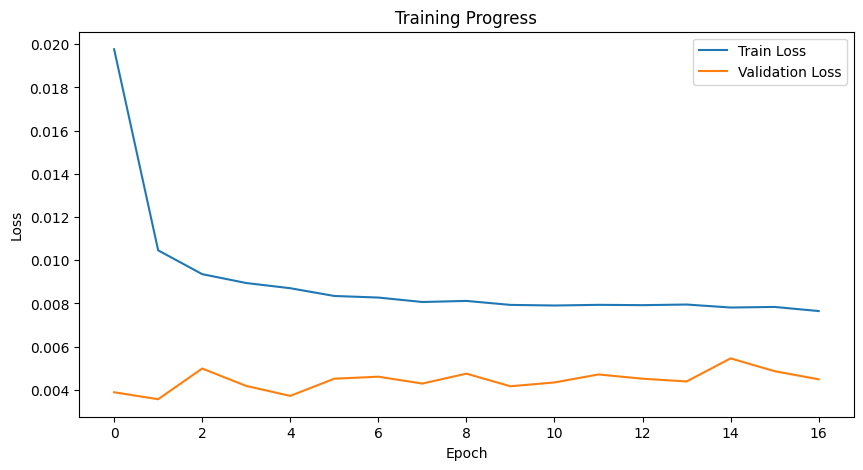

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

# Full Dataset Evaluation

In [ ]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, _ = batch
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu())
        all_targets.append(targets)

preds   = torch.cat(all_preds).numpy().flatten()
targets = torch.cat(all_targets).numpy().flatten()

from sklearn.metrics import r2_score, mean_absolute_error
print(f"Pred range:            {preds.min():.4f} - {preds.max():.4f}")
print(f"Pred mean:             {preds.mean():.4f}  (target mean: {targets.mean():.4f})")
print(f"High CISI pred mean:   {preds[targets > 0.2].mean():.4f}")
print(f"High CISI target mean: {targets[targets > 0.2].mean():.4f}")
print(f"City underprediction:  {(1 - preds[targets>0.2].mean()/targets[targets>0.2].mean())*100:.1f}%")
print(f"\nGlobal R2:  {r2_score(targets, preds):.4f}")
print(f"Global MAE: {mean_absolute_error(targets, preds):.4f}")
print(f"City R2:    {r2_score(targets[targets>0.2], preds[targets>0.2]):.4f}")
print(f"City MAE:   {mean_absolute_error(targets[targets>0.2], preds[targets>0.2]):.4f}")

Pred range:            0.0650 - 0.4675
Pred mean:             0.0858  (target mean: 0.0302)
High CISI pred mean:   0.1653
High CISI target mean: 0.2781
City underprediction:  40.6%

Global R2:  -1.7752
Global MAE: 0.0604
City R2:    -2.9991
City MAE:   0.1194


In [ ]:
# Load best model (Exp102)
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, _ = batch
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu())
        all_targets.append(targets)

preds = torch.cat(all_preds).numpy().flatten()
targets = torch.cat(all_targets).numpy().flatten()

# Diagnostics
print(f"Pred range: {preds.min():.4f} - {preds.max():.4f}")
print(f"Pred mean: {preds.mean():.4f}")
print(f"Target mean: {targets.mean():.4f}")
print(f"High CISI pixels (>0.2): {(targets > 0.2).mean()*100:.1f}%")
print(f"High CISI pred mean: {preds[targets > 0.2].mean():.4f}")
print(f"High CISI target mean: {targets[targets > 0.2].mean():.4f}")

Pred range: 0.0650 - 0.4739
Pred mean: 0.0860
Target mean: 0.0302
High CISI pixels (>0.2): 0.8%
High CISI pred mean: 0.1640
High CISI target mean: 0.2781


# Generate predictions

In [ ]:
model.eval()
predictions = []
actuals = []
coordinates = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, coords = batch
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        predictions.extend(outputs.cpu().numpy().flatten())
        actuals.extend(targets.numpy().flatten())
        coordinates.extend(coords)

predictions = np.array(predictions)
actuals = np.array(actuals)

print(f"Predictions range: [{predictions.min():.3f}, {predictions.max():.3f}]")
print(f"Actuals range: [{actuals.min():.3f}, {actuals.max():.3f}]")

Predictions range: [0.065, 0.407]
Actuals range: [0.000, 0.585]


# Visualize Results

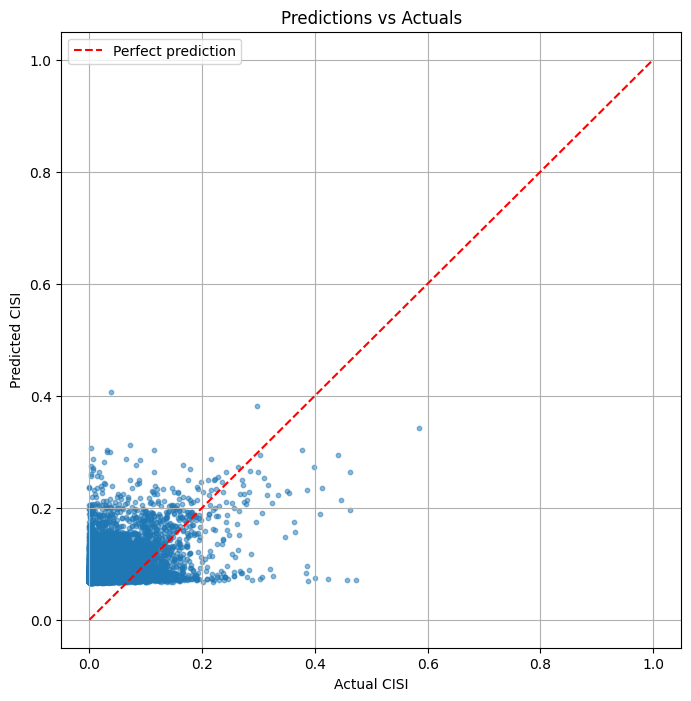

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.5, s=10)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual CISI')
plt.ylabel('Predicted CISI')
plt.title('Predictions vs Actuals')
plt.legend()
plt.grid(True)
plt.show()

# Metrics

In [ ]:
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 0.0044
MAE: 0.0604
RMSE: 0.0666
R² Score: -1.7776


=== ACTUALS ===
Mean: 0.0302
Std: 0.0400
Range: [0.0000, 0.5846]

=== PREDICTIONS ===
Mean: 0.0858
Std: 0.0259
Range: [0.0650, 0.4069]


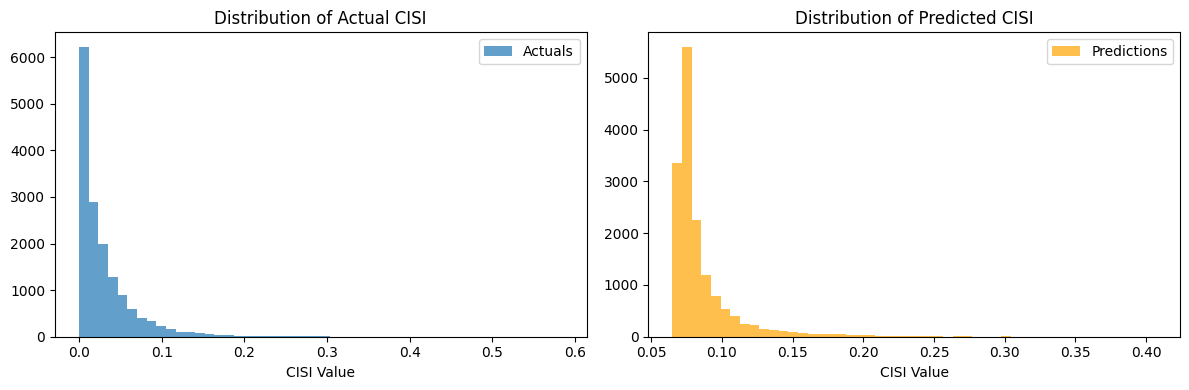

In [ ]:
# Check distributions
print("=== ACTUALS ===")
print(f"Mean: {actuals.mean():.4f}")
print(f"Std: {actuals.std():.4f}")
print(f"Range: [{actuals.min():.4f}, {actuals.max():.4f}]")

print("\n=== PREDICTIONS ===")
print(f"Mean: {predictions.mean():.4f}")
print(f"Std: {predictions.std():.4f}")
print(f"Range: [{predictions.min():.4f}, {predictions.max():.4f}]")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(actuals, bins=50, alpha=0.7, label='Actuals')
axes[0].set_title('Distribution of Actual CISI')
axes[0].set_xlabel('CISI Value')
axes[0].legend()

axes[1].hist(predictions, bins=50, alpha=0.7, label='Predictions', color='orange')
axes[1].set_title('Distribution of Predicted CISI')
axes[1].set_xlabel('CISI Value')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Look at one sample from dataset
sample_input, sample_target, _ = dataset[0]

print("Input shape:", sample_input.shape)
print("\nInput statistics per channel:")
for i in range(9):
    channel = sample_input[i]
    print(f"Channel {i}: min={channel.min():.2f}, max={channel.max():.2f}, mean={channel.mean():.2f}")

print(f"\nTarget CISI value: {sample_target.item():.4f}")

Input shape: torch.Size([9, 16, 16])

Input statistics per channel:
Channel 0: min=-0.80, max=1.66, mean=-0.56
Channel 1: min=-1.46, max=0.89, mean=-0.86
Channel 2: min=0.00, max=0.00, mean=0.00
Channel 3: min=0.00, max=1.00, mean=0.03
Channel 4: min=0.00, max=1.00, mean=0.57
Channel 5: min=0.00, max=1.00, mean=0.26
Channel 6: min=0.00, max=0.00, mean=0.00
Channel 7: min=0.00, max=1.00, mean=0.04
Channel 8: min=0.00, max=1.00, mean=0.10

Target CISI value: 0.0000


# Generate Predictions on Full Training Set

In [ ]:
# # Generate predictions on ALL training data
# model.eval()
# all_preds = []
# all_actuals = []
# all_indices = []

# with torch.no_grad():
#     for inputs, targets, indices in train_loader:
#         inputs = inputs.to(device)
#         outputs = model(inputs)
        
#         all_preds.extend(outputs.cpu().numpy().flatten())
#         all_actuals.extend(targets.cpu().numpy().flatten())
#         all_indices.extend(indices)

# all_preds = np.array(all_preds)
# all_actuals = np.array(all_actuals)

# # Split by city/rural
# city_mask = all_actuals > 0.1
# rural_mask = all_actuals <= 0.1

# print(f"\n{'='*80}")
# print("TRAINING SET: CITY vs RURAL")
# print(f"{'='*80}")

# print(f"\n CITIES (CISI > 0.1):")
# print(f"  Count: {city_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[city_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[city_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[city_mask], all_preds[city_mask]):.4f}")

# print(f"\n RURAL (CISI ≤ 0.1):")
# print(f"  Count: {rural_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[rural_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[rural_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[rural_mask], all_preds[rural_mask]):.4f}")

# Save model

In [ ]:
save_model_checkpoint(
    model, optimizer, train_loss_list, val_loss_list, config,
    save_name='exp111',
    dataset=dataset,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    criterion=criterion,
    learning_rate=0.0005,
    batch_size=batch_size,
    num_epochs=nummber_of_epochs,
    patch_size=32
)

Saved: models/cisi_model_exp110.pth


# Weights & Biases Hyperparameter Sweep

# Huber Loss Test

In [ ]:
# from sklearn.metrics import r2_score, mean_absolute_error

# huber_results = {}

# for delta in [0.1, 0.3, 0.5]:
#     print(f"\n--- Huber delta={delta} ---")

#     m_h = CNN({'dropout': 0.3}).to(device)
#     crit_h = torch.nn.HuberLoss(delta=delta)
#     opt_h = torch.optim.Adam(m_h.parameters(), lr=0.0005)
#     sched_h = torch.optim.lr_scheduler.CosineAnnealingLR(opt_h, T_max=50, eta_min=1e-6)
#     es_h = EarlyStopping(patience=15, delta=0.0001)

#     for epoch in range(50):
#         m_h.train()
#         for inputs, targets, _ in train_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             opt_h.zero_grad()
#             loss = crit_h(m_h(inputs), targets)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(m_h.parameters(), 1.0)
#             opt_h.step()
#         sched_h.step()

#         m_h.eval()
#         val_losses = []
#         with torch.no_grad():
#             for inputs, targets, _ in val_loader:
#                 inputs, targets = inputs.to(device), targets.to(device)
#                 val_losses.append(crit_h(m_h(inputs), targets).item())
#         es_h(np.mean(val_losses))
#         if es_h.early_stop:
#             print(f"  Early stop at epoch {epoch+1}")
#             break

#     m_h.eval()
#     all_preds, all_targets = [], []
#     with torch.no_grad():
#         for inputs, targets, _ in val_loader:
#             all_preds.append(m_h(inputs.to(device)).cpu().numpy())
#             all_targets.append(targets.numpy())

#     preds_h   = np.concatenate(all_preds).flatten()
#     targets_h = np.concatenate(all_targets).flatten()
#     city_mask = targets_h > 0.2

#     global_r2   = r2_score(targets_h, preds_h)
#     city_r2     = r2_score(targets_h[city_mask], preds_h[city_mask])
#     city_underp = (1 - preds_h[city_mask].mean() / targets_h[city_mask].mean()) * 100
#     pred_max    = preds_h.max()

#     huber_results[delta] = {'global_r2': global_r2, 'city_r2': city_r2,
#                              'city_underprediction': city_underp, 'pred_max': pred_max}

#     print(f"  Global R2={global_r2:.4f}, City R2={city_r2:.4f}, City underp={city_underp:.1f}%, Pred max={pred_max:.3f}")

# print("\n=== Huber Loss Summary ===")
# for delta, res in huber_results.items():
#     print(f"  delta={delta}: Global R2={res['global_r2']:.4f}, City underp={res['city_underprediction']:.1f}%, Pred max={res['pred_max']:.3f}")


--- Huber delta=0.1 ---
  Early stop at epoch 16
  Global R2=0.1699, City R2=-9.5266, City underp=81.4%, Pred max=0.105

--- Huber delta=0.3 ---
  Early stop at epoch 20
  Global R2=0.1833, City R2=-8.8197, City underp=78.4%, Pred max=0.147

--- Huber delta=0.5 ---
  Early stop at epoch 16
  Global R2=0.1980, City R2=-8.4143, City underp=76.7%, Pred max=0.166

=== Huber Loss Summary ===
  delta=0.1: Global R2=0.1699, City underp=81.4%, Pred max=0.105
  delta=0.3: Global R2=0.1833, City underp=78.4%, Pred max=0.147
  delta=0.5: Global R2=0.1980, City underp=76.7%, Pred max=0.166


In [1]:
import csv
import random
from sklearn.metrics import r2_score, mean_absolute_error

random.seed(42)

param_grid = [
    {
        'kappa':   random.uniform(5.0, 60.0),
        'alpha':   random.uniform(1.5, 5.0),
        'lr':      random.uniform(0.0001, 0.001),
        'dropout': random.choice([0.1, 0.2, 0.3, 0.4]),
    }
    for _ in range(30)
]

results_path = "hyperparameter_search_results.csv"
print(f"Running {len(param_grid)} configurations...")

Running 30 configurations...


In [24]:
import os

fieldnames = ['kappa', 'alpha', 'lr', 'dropout', 'global_r2', 'global_mae', 'city_r2', 'city_mae', 'city_underprediction', 'pred_max']
best_model_path = "best_search_model.pt"

# Resume: load already-completed runs from CSV
results = []
completed = 0
if os.path.exists(results_path):
    with open(results_path, 'r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            results.append({k: float(v) for k, v in row.items()})
    completed = len(results)
    print(f"Resuming — {completed} runs already done, skipping to run {completed+1}")
else:
    with open(results_path, 'w', newline='') as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()

best_city_underpred = min((r['city_underprediction'] for r in results), default=float('inf'))

for i, params in enumerate(param_grid):
    if i < completed:
        continue

    print(f"\nRun {i+1}/30 — kappa={params['kappa']:.1f}, alpha={params['alpha']:.2f}, lr={params['lr']:.5f}, dropout={params['dropout']}")

    m = CNN({'dropout': params['dropout']}).to(device)
    crit = WeibullWeightedMSELoss(kappa=params['kappa'], alpha=params['alpha'])
    opt = torch.optim.Adam(m.parameters(), lr=params['lr'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50, eta_min=1e-6)
    es = EarlyStopping(patience=15, delta=0.0001)

    for epoch in range(50):
        m.train()
        for inputs, targets, _ in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            opt.zero_grad()
            loss = crit(m(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sched.step()

        m.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, targets, _ in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                val_losses.append(crit(m(inputs), targets).item())
        es(np.mean(val_losses))
        if es.early_stop:
            print(f"  Early stop at epoch {epoch+1}")
            break

    m.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            all_preds.append(m(inputs.to(device)).cpu().numpy())
            all_targets.append(targets.numpy())

    preds   = np.concatenate(all_preds).flatten()
    targets = np.concatenate(all_targets).flatten()
    city_mask = targets > 0.2

    row = {
        **params,
        'global_r2':            r2_score(targets, preds),
        'global_mae':           mean_absolute_error(targets, preds),
        'city_r2':              r2_score(targets[city_mask], preds[city_mask]),
        'city_mae':             mean_absolute_error(targets[city_mask], preds[city_mask]),
        'city_underprediction': (1 - preds[city_mask].mean() / targets[city_mask].mean()) * 100,
        'pred_max':             preds.max(),
    }
    results.append(row)

    with open(results_path, 'a', newline='') as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

    if row['city_underprediction'] < best_city_underpred:
        best_city_underpred = row['city_underprediction']
        torch.save({'model_state_dict': m.state_dict(), 'params': params}, best_model_path)
        print(f"  *** New best model saved (city_underpred={best_city_underpred:.1f}%)")

    print(f"  Global R2={row['global_r2']:.4f}, City underp={row['city_underprediction']:.1f}%, Pred max={row['pred_max']:.3f}")

best = min(results, key=lambda x: x['city_underprediction'])
print(f"\nBest: kappa={best['kappa']:.1f}, alpha={best['alpha']:.2f}, lr={best['lr']:.5f}, dropout={best['dropout']}")
print(f"  Global R2={best['global_r2']:.4f}, City underp={best['city_underprediction']:.1f}%, City R2={best['city_r2']:.4f}")
print(f"  Best model saved to: {best_model_path}")

Resuming — 9 runs already done, skipping to run 10

Run 10/30 — kappa=9.3, alpha=2.53, lr=0.00067, dropout=0.3
  Early stop at epoch 22
  Global R2=0.1814, City underp=78.3%, Pred max=0.119

Run 11/30 — kappa=36.8, alpha=3.97, lr=0.00014, dropout=0.2
  Early stop at epoch 27
  *** New best model saved (city_underpred=73.2%)
  Global R2=0.2116, City underp=73.2%, Pred max=0.273

Run 12/30 — kappa=47.5, alpha=4.95, lr=0.00087, dropout=0.1
  Early stop at epoch 23
  *** New best model saved (city_underpred=70.3%)
  Global R2=0.2212, City underp=70.3%, Pred max=0.244

Run 13/30 — kappa=25.9, alpha=3.09, lr=0.00085, dropout=0.2
  Early stop at epoch 19
  Global R2=0.2171, City underp=71.3%, Pred max=0.173

Run 14/30 — kappa=25.4, alpha=2.23, lr=0.00034, dropout=0.1
  Early stop at epoch 22
  Global R2=0.2241, City underp=71.0%, Pred max=0.321

Run 15/30 — kappa=38.5, alpha=2.10, lr=0.00076, dropout=0.2
  Early stop at epoch 22
  Global R2=0.2159, City underp=74.9%, Pred max=0.177

Run 16/30

KeyboardInterrupt: 

# Debugging checks

In [ ]:
# import torch
# import numpy as np

# print("=" * 70)
# print("CHECKING FIRST BATCH FROM DATALOADER")
# print("=" * 70)

# # Get one batch
# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     print(f"\nBatch {batch_idx}:")
#     print(f"  Batch size: {inputs.shape[0]}")
#     print(f"  Input shape: {inputs.shape}")  # Should be (batch, 9, 32, 32)
#     print(f"  Target shape: {targets.shape}")  # Should be (batch, 1)
    
#     # Check for NaN/Inf in inputs
#     print(f"\n  INPUT CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(inputs).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(inputs).any().item()}")
#     print(f"    Min: {inputs.min().item():.4f}")
#     print(f"    Max: {inputs.max().item():.4f}")
#     print(f"    Mean: {inputs.mean().item():.4f}")
    
#     # Check for NaN/Inf in targets
#     print(f"\n  TARGET CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(targets).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(targets).any().item()}")
#     print(f"    Min: {targets.min().item():.4f}")
#     print(f"    Max: {targets.max().item():.4f}")
#     print(f"    Mean: {targets.mean().item():.4f}")
    
#     # Check each channel individually
#     print(f"\n  PER-CHANNEL CHECKS:")
#     channel_names = ['GDP', 'Pop', 'LC_0', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6']
#     for ch in range(9):
#         ch_data = inputs[:, ch, :, :]
#         has_nan = torch.isnan(ch_data).any().item()
#         has_inf = torch.isinf(ch_data).any().item()
#         print(f"    {channel_names[ch]:6s}: min={ch_data.min().item():7.2f}, "
#               f"max={ch_data.max().item():7.2f}, "
#               f"NaN={has_nan}, Inf={has_inf}")
    
#     # Only check first batch
#     break

# print("\n" + "=" * 70)

In [ ]:
# print("=" * 70)
# print("TESTING FORWARD PASS")
# print("=" * 70)

# model.eval()  # Set to eval mode first
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# with torch.no_grad():
#     for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device).view(-1, 1)
        
#         print(f"\nBatch {batch_idx}:")
#         print(f"  Input device: {inputs.device}")
#         print(f"  Input requires_grad: {inputs.requires_grad}")
        
#         # Forward pass
#         try:
#             outputs = model(inputs)
            
#             print(f"\n  OUTPUT CHECKS:")
#             print(f"    Output shape: {outputs.shape}")
#             print(f"    Contains NaN: {torch.isnan(outputs).any().item()}")
#             print(f"    Contains Inf: {torch.isinf(outputs).any().item()}")
#             print(f"    Min: {outputs.min().item():.4f}")
#             print(f"    Max: {outputs.max().item():.4f}")
#             print(f"    Mean: {outputs.mean().item():.4f}")
            
#             # Compute loss
#             loss = criterion(outputs, targets)
#             print(f"\n  LOSS:")
#             print(f"    Loss value: {loss.item():.4f}")
#             print(f"    Loss is NaN: {torch.isnan(loss).item()}")
#             print(f"    Loss is Inf: {torch.isinf(loss).item()}")
            
#         except Exception as e:
#             print(f"   ERROR during forward pass: {e}")
#             import traceback
#             traceback.print_exc()
        
#         # Only test first batch
#         break

# print("\n" + "=" * 70)

In [ ]:
# print("=" * 70)
# print("DEBUGGING ONE TRAINING STEP")
# print("=" * 70)

# model.train()

# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     inputs = inputs.to(device)
#     targets = targets.to(device).view(-1, 1)
    
#     print(f"\n=== STEP {batch_idx} ===")
    
#     # Zero gradients
#     optimizer.zero_grad()
    
#     # Forward
#     print("1. Forward pass...")
#     outputs = model(inputs)
#     print(f"   Outputs: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, "
#           f"NaN={torch.isnan(outputs).any().item()}")
    
#     # Loss
#     print("2. Computing loss...")
#     loss = criterion(outputs, targets)
#     print(f"   Loss: {loss.item():.4f}, NaN={torch.isnan(loss).item()}")
    
#     if torch.isnan(loss):
#         print("    NaN DETECTED IN LOSS!")
#         print(f"   Sample outputs: {outputs[:5].squeeze()}")
#         print(f"   Sample targets: {targets[:5].squeeze()}")
#         break
    
#     # Backward
#     print("3. Backward pass...")
#     loss.backward()
    
#     # Check gradients
#     print("4. Checking gradients...")
#     total_norm = 0
#     max_grad = 0
#     nan_grads = False
    
#     for name, param in model.named_parameters():
#         if param.grad is not None:
#             grad_norm = param.grad.data.norm(2).item()
#             total_norm += grad_norm ** 2
#             max_grad = max(max_grad, param.grad.abs().max().item())
            
#             if torch.isnan(param.grad).any():
#                 print(f"    NaN gradient in {name}")
#                 nan_grads = True
    
#     total_norm = total_norm ** 0.5
#     print(f"   Total gradient norm: {total_norm:.4f}")
#     print(f"   Max gradient value: {max_grad:.4f}")
    
#     if nan_grads:
#         print("    NaN DETECTED IN GRADIENTS!")
#         break
    
#     if total_norm > 1000:
#         print(f"    WARNING: Very large gradients! (norm={total_norm:.2f})")
    
#     # Clip
#     print("5. Clipping gradients...")
#     torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
#     # Step
#     print("6. Optimizer step...")
#     optimizer.step()
    
#     print("    Step complete\n")
    
#     # Only do 3 steps
#     if batch_idx >= 2:
#         break

# print("\n" + "=" * 70)

In [ ]:
print("=" * 70)
print("CHECKING MODEL WEIGHTS")
print("=" * 70)

print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"  {name:40s}: shape={str(list(param.shape)):20s} "
          f"mean={param.data.mean().item():8.4f} "
          f"std={param.data.std().item():8.4f} "
          f"NaN={torch.isnan(param.data).any().item()}")

print("\n" + "=" * 70)

CHECKING MODEL WEIGHTS

Model parameters:
  conv_layers.0.weight                    : shape=[16, 9, 3, 3]        mean=  0.0014 std=  0.1171 NaN=False
  conv_layers.0.bias                      : shape=[16]                 mean= -0.0078 std=  0.0733 NaN=False
  conv_layers.1.weight                    : shape=[16]                 mean=  0.9703 std=  0.0592 NaN=False
  conv_layers.1.bias                      : shape=[16]                 mean= -0.2601 std=  0.1435 NaN=False
  conv_layers.5.weight                    : shape=[32, 16, 3, 3]       mean= -0.0030 std=  0.0913 NaN=False
  conv_layers.5.bias                      : shape=[32]                 mean= -0.0030 std=  0.0462 NaN=False
  conv_layers.6.weight                    : shape=[32]                 mean=  0.9888 std=  0.0660 NaN=False
  conv_layers.6.bias                      : shape=[32]                 mean= -0.2024 std=  0.1038 NaN=False
  conv_layers.10.weight                   : shape=[64, 32, 3, 3]       mean= -0.0006 std=  0.0

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_38188\2250598502.py:9: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  f"std={param.data.std().item():8.4f} "


In [ ]:
# Check if 0.1° CISI file is correct
with rasterio.open(cisi_path) as src:
    cisi = src.read(1)
    print(f"CISI shape: {cisi.shape}")
    print(f"CISI range: [{np.nanmin(cisi):.4f}, {np.nanmax(cisi):.4f}]")
    print(f"Valid pixels: {(~np.isnan(cisi)).sum():,}")
    print(f"Non-zero CISI: {(cisi > 0).sum():,}")

# Check alignment with GDP
with rasterio.open(gdp_path) as src:
    gdp = src.read(1)
    print(f"\nGDP shape: {gdp.shape}")
    print(f"GDP valid: {(~np.isnan(gdp)).sum():,}")

# Check dataset
print(f"\nDataset valid indices: {len(dataset.valid_indices):,}")

CISI shape: (485, 570)
CISI range: [0.0000, 0.8959]
Valid pixels: 87,346
Non-zero CISI: 78,532

GDP shape: (485, 570)
GDP valid: 89,397

Dataset valid indices: 77,935


In [ ]:
import os
from pathlib import Path

# Check current working directory
print(f"Current directory: {os.getcwd()}")

# List files in current directory
print("\nFiles in current directory:")
for file in Path('.').glob('*.pth'):
    print(f"  ✅ {file}")

# Also check common locations
locations_to_check = [
    '.',
    './models',
    '../',
    str(Path.home() / 'Downloads'),
]

print("\nSearching for .pth files...")
for loc in locations_to_check:
    if os.path.exists(loc):
        pth_files = list(Path(loc).glob('**/*.pth'))
        if pth_files:
            print(f"\n📁 Found in {loc}:")
            for f in pth_files:
                print(f"  ✅ {f}")

Current directory: c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis

Files in current directory:
  ✅ cisi_model_2024.pth

Searching for .pth files...

📁 Found in .:
  ✅ cisi_model_2024.pth
  ✅ models\cisi_model_exp100.pth
  ✅ models\cisi_model_exp100b.pth
  ✅ models\cisi_model_exp101.pth
  ✅ models\cisi_model_exp102.pth
  ✅ models\cisi_model_exp103.pth
  ✅ models\cisi_model_exp104.pth
  ✅ models\cisi_model_exp105.pth
  ✅ models\cisi_model_exp106.pth
  ✅ models\cisi_model_exp107.pth
  ✅ models\cisi_model_exp108.pth
  ✅ models\cisi_model_exp109.pth
  ✅ models\cisi_model_exp110.pth
  ✅ models_old\cisi_model_exp10.pth
  ✅ models_old\cisi_model_exp11.pth
  ✅ models_old\cisi_model_exp12_bilinear.pth
  ✅ models_old\cisi_model_exp13.pth
  ✅ models_old\cisi_model_exp14_nearest.pth
  ✅ models_old\cisi_model_exp15_clamp.pth
  ✅ models_old\cisi_model_exp16.pth
  ✅ models_old\cisi_model_exp17_weight100_1_5t.pth
  ✅ models_old\cisi_model_exp18_kfold.pth
  ✅ models_old\cisi_mode

In [ ]:
print(f"Pred min: {predictions.min():.4f}")
print(f"Pred max: {predictions.max():.4f}")
print(f"Actual min: {actuals.min():.4f}")
print(f"Actual max: {actuals.max():.4f}")

Pred min: 0.0650
Pred max: 0.4069
Actual min: 0.0000
Actual max: 0.5846


In [ ]:
import rasterio
import numpy as np

with rasterio.open(cisi_path) as src:
    cisi_data = src.read(1)
    print(f"CISI file max: {np.nanmax(cisi_data):.4f}")
    print(f"CISI file 99th percentile: {np.percentile(cisi_data[~np.isnan(cisi_data)], 99):.4f}")

CISI file max: 0.8959
CISI file 99th percentile: 0.1833
